# Queuing Simulation from First Principles 

## One server, one queue - M/M/1
### A simple sketch of a queue simulation
For those of you who like to have a "sense" of what we are doing, before doing it, here is a brief overview of how to put together a queueing simulation.
If you are more fool-hardy - feel free to skip it and get to the code below.

An $M/M/1$ queue is a single server queue with first-come first-served scheduling of customers. 
- Poisson arrival process with parameter $\lambda$, i.e., interarrival times have an Exponential distribution with mean $1/\lambda$ (we will cover this in a later lecture!);
- Exponentially distributed service time with rate $\mu$ and mean service time $1/\mu$.
	
There are several variables that we need to specify:
- An integer $n$ to characterize the state of the system (e.g. total number of people).
- The variable $t$ tracks the internal clock time and variables  and $t_d$ denote the scheduled times of the next arrival and the next departure.
- The only two events that can occur: 
    - arrival of a new customer to the system: $n_a$ in total, $t_a$ next arrival time, $t_\lambda$ interarrival times,
	- departure of a customer who completed service: $n_d$ in total, $t_d$ next departure, $t_\mu$ service times.
- A termination criteria, e.g. run the simulation until :
    - a total of $N$ customers have been served,
    - a total simulation time of $T$ has been reached.
- Decide which metrics you want to compute (so you know what information needs saving or if you need to structure your code in some way!): 
    - e.g. mean interarrival time, mean service time and mean time spent waiting in the queue.
	
>The Method (loosely):
>1. Advance the internal clock to the next event - earliest time of arrival $t_a$ or time of departure $t_d$, that is: $t = t + min(t_a, t_d)$, 
>2. Modify the system state $n$ appropriately (e.g. +1 for arrival, -1 for departure),
>3. Increment the respective system states: $n_a$ and $n_d$, for counting arrivals and departures, 
>4. Compute time to next event: $t_a = t + t_\lambda$, $t_d = t + t_\mu$,
>5. Repeat steps 1-4 until your termination criteria is met: $t > T$ or $n > N$.
>6. Generate system statistics/metrics.

# Building the M/M/1 queue model
First, we import the necessary libraries.

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from collections import deque

The following code defines a class named `Simulation`.

Technical information if interested:
> - A *class* is a code template for creating *objects*.
> - *Objects* have member *variables* and a *behaviour* associated with them. 
>
> i.e. having defined the Simulation class, calling: ```s = Simulation(lam, mu)``` in python code establishes an object with the properties (variable and behaviours) outlined in the code below.
> 
> In python a class is created by the keyword ```class```. 
> An object is created using the *constructor* of the class. 
> This object will then be called the instance of the class.

 `Simulation` simulates a queueing system using two key parameters: **`lambda_rate` (arrival rate , $\lambda$)** and **`mu_rate` (service rate, $\mu$)**. This class models the arrival and departure of customers in a system over time, including tracking customers and their wait times. 

 REMEMBER: the arrival rates and service rates here associate with Markovian processes and are the rate parameters of a Poisson process and Exponential distribution respectively.

The `Simulation` class contains several key methods:
- **`__init__()`**: Initialises the:
    - simulation with arrival and service rates, 
    - system state, and 
    - prepares the necessary variables for tracking events.
- **`advance_time()`**: 
    - Advances the simulation time to the next event (either an arrival or departure), and 
    - updates the system variables accordingly.
- **`arrival()`**: 
    - Handles the event of a customer arriving, 
    - Updates the system state, and 
    - Schedules the next departure, if necessary.
- **`departure()`**: 
    - Handles the event of a customer departing, 
    - Updates the system state, 
    - Records the wait time, and 
    - Schedules the next departure, if required.
- **`generate_interarrival()`** and **`generate_service()`**: Generate the inter-arrival and service times using exponential distributions.

In [2]:
class Simulation:
    # Constructor to initialise simulation parameters and state
    def __init__(self, lambda_rate, mu_rate):
        self.lambda_rate = lambda_rate                  # Arrival rate (lambda) - user defined
        self.mu_rate = mu_rate                          # Service rate (mu) - user defined
        self.num_in_system = 0                          # System begins empty - no one is in the system at t = 0
        self.clock = 0.0                                # Simulation begins at time t = 0
        self.t_arrival = self.generate_interarrival()   # Generate the first inter-arrival time based on the arrival rate (lambda) - generate_interarrival() is a user defined function below.
        self.t_depart = float('inf')                    # Set initial departure time to infinity, since there are initially no customers in the service             
        self.waits = []                                 # Creates a list to track waiting times for each customer
        self.total_wait = 0.0                           # Creares a variable for storing the total waiting time
        self.in_systems = [(0, 0)]                      # Track customers in the system with their arrival/departure times and the queue lengths
        self.queue = deque()                            # Initialises an empty queue to manage customer arrivals

    # COMMENT ON DEQUE: A deque stands for Double-Ended Queue. It is a data structure that allows adding and removing elements from both ends efficiently. 
    # Unlike regular queues, which are typically operated on using FIFO (First In, First Out) principles, a deque supports both FIFO and LIFO (Last In, First Out) operations.
    
    # Method to advance the simulation time to the next event (either arrival or departure)
    def advance_time(self):
        # Determine the next event by selecting the earliest time (arrival or departure)
        t_event = min(self.t_arrival, self.t_depart)

        # Update the total wait time based on the number of customers currently in the system
        self.total_wait += self.num_in_system * (t_event - self.clock)
        self.clock = t_event  # Advance the clock to the time of the next event
        
        # If the next event is an arrival, process the arrival; otherwise, process the departure
        if self.t_arrival <= self.t_depart:
            self.arrival()
        else:
            self.departure()
    
    # Method to handle the arrival of a customer
    def arrival(self):
        self.num_in_system += 1                         # Increase the number of customers in the system by 1
        self.queue.append(self.clock)                   # Add the current time to the queue (arrival time of the customer)
        self.in_systems.append((self.clock,len(self.queue)))

        ## COMMENT ON APPEND: Adds an element to the end of a list/array, e.g. 
        # X = [1, 2, 3]

        ## append '4' to the list
        # currencies.append([4])
        # print(X)
        ## Output: [1, 2, 3, 4]

        # Log the customer arrival, including the number of customers before and after
        print('%g: customer arrives (num_in_system=%d->%d)' % (self.t_arrival, self.num_in_system-1, self.num_in_system))

        # If the system was empty before the arrival, schedule a departure time for this customer - self.generate_service USER DEFINED function below
        if self.num_in_system <= 1:
            self.t_depart = self.clock + self.generate_service()
        
        # Generate the next inter-arrival time for the next customer - self.generate_interarrival USER DEFINED function below
        self.t_arrival = self.clock + self.generate_interarrival()
    
    # Method to handle the departure of a customer
    def departure(self):
        # Decrease the number of customers in the system
        self.num_in_system -= 1
        
        # Log the customer departure, including the number of customers before and after
        print('%g: customer departs (num_in_system=%d->%d)' % (self.t_depart, self.num_in_system+1, self.num_in_system))
        
        # Record the wait time for the departed customer by calculating the difference
        # between current time and the customer's arrival time (which is stored in the queue)
        t = self.queue.popleft()
        self.in_systems.append((self.clock, len(self.queue)))
        self.waits.append(self.clock - t)
        
        # If there are still customers in the system, schedule the next departure time
        if self.num_in_system > 0:
            self.t_depart = self.clock + self.generate_service()
        else:
            # If the system is empty, set the departure time to infinity
            self.t_depart = float('inf')
    
    # Method to generate inter-arrival times using an exponential distribution
    def generate_interarrival(self):
        return np.random.exponential(1. / self.lambda_rate)
    
    # Method to generate service times using an exponential distribution
    def generate_service(self):
        return np.random.exponential(1. / self.mu_rate)


Building on the `Simulation` class, the following code sets up and runs a simulation of a queueing system for:
- a specified `duration` 
- using **`lambda_rate`** and **`mu_rate`** calculated from `1 / interarrival_time` and `1 / service_time`, respectively. 

So, there are three parameters the user can define and vary.

By initialising a `Simulation` object, the `advance_time()` method can be repeatedly called to simulate the passage of time and the corresponding events. 
- e.g. `advance_time()` evaluates what the next event is, advances time, initiates the event and updates all related parameters ready for the next iteration (check you are happy with this in the `Simulation` class above).

To test the simulation, set the `interarrival_time` to 8 minutes, the `service_time` to 5 minutes, and the `duration` to 100 minutes.

In [3]:
np.random.seed(0) # Set the random seed for reproducibility

# Define the average inter-arrival time and service time (in minutes)
interarrival_time = 1/5      # Average time between customer arrivals
service_time = 1/8         # Average service time per customer

# Calculate the arrival rate (lambda) and service rate (mu) from the given times
lam = 1 / interarrival_time # Arrival rate (lambda)
mu = 1 / service_time       # Service rate (mu)

# Create a new Simulation object with the calculated arrival and service rates
s = Simulation(lam, mu)

# Define the total duration for the simulation in minutes
duration = 100

# Run the simulation by advancing the time until the clock reaches the specified duration
while s.clock < duration:
    s.advance_time() 

# After the simulation ends, print the first three wait times of customers
print('Wait times: %r...' % s.waits[:3])  # Show the first 3 customers' wait times
# Print the first three entries in the system (arrival time and queue size at each point)
print('Number of customers in system: %r...' % s.in_systems[:3])  # Show the first 3 system states (time and queue length)


0.159175: customer arrives (num_in_system=0->1)
0.316166: customer departs (num_in_system=1->0)
0.34382: customer arrives (num_in_system=0->1)
0.44222: customer departs (num_in_system=1->0)
0.454029: customer arrives (num_in_system=0->1)
0.569133: customer arrives (num_in_system=1->2)
0.583799: customer departs (num_in_system=2->1)
0.998163: customer departs (num_in_system=1->0)
1.01384: customer arrives (num_in_system=0->1)
1.07429: customer departs (num_in_system=1->0)
1.32762: customer arrives (num_in_system=0->1)
1.4217: customer departs (num_in_system=1->0)
1.4955: customer arrives (num_in_system=0->1)
1.51024: customer arrives (num_in_system=1->2)
1.52847: customer arrives (num_in_system=2->3)
1.53256: customer arrives (num_in_system=3->4)
1.82029: customer departs (num_in_system=4->3)
1.89006: customer arrives (num_in_system=3->4)
2.00851: customer departs (num_in_system=4->3)
2.29812: customer arrives (num_in_system=3->4)
2.48916: customer departs (num_in_system=4->3)
2.56653: 

### Plot the number of customers in the system at each time step to visualise how the queue evolves over time.

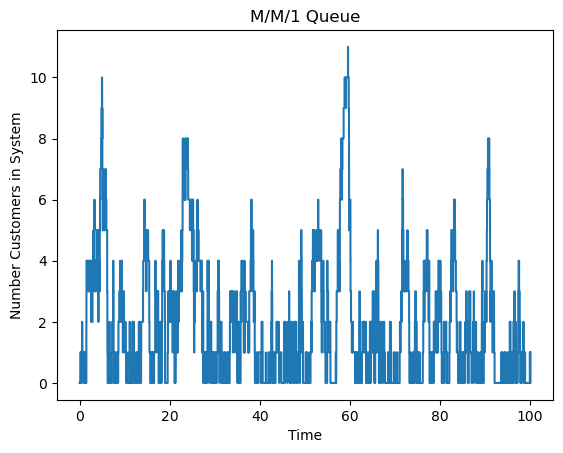

In [4]:
# Create a step plot using the time and queue length data from the simulation
plt.step(*zip(*s.in_systems[:]), where='post')  # The asterisk '*' here performs a special task - look it up online! Or see below
plt.title("M/M/1 Queue")                        # Set the title of the plot
plt.xlabel("Time")                              # Label the x-axis as 'Time'
plt.ylabel("Number Customers in System")        # Label the y-axis as 'Number of Customers in System'
plt.show()                                      # Display the plot

#### Aside: 
To see what the asterixes are doing in the above code, let's print the contents of s.in_systems first using:

In [5]:
print(s.in_systems[:])

[(0, 0), (0.15917490163262202, 1), (0.3161662470033517, 0), (0.3438195307934358, 1), (0.44221967483309466, 0), (0.4540292290125357, 1), (0.5691330688462637, 2), (0.5837991408804868, 1), (0.9981631636372135, 0), (1.013837951452795, 1), (1.0742882140655767, 0), (1.3276171794466287, 1), (1.4217014431387023, 0), (1.4955037487943934, 1), (1.510240819776963, 2), (1.528473025600763, 3), (1.532558142937608, 4), (1.8202855180350734, 3), (1.8900556788605858, 4), (2.0085085470182253, 3), (2.2981185350496958, 4), (2.4891612767890816, 3), (2.5665274591157026, 2), (2.619166446839725, 3), (2.6443413292058335, 4), (2.7560944562257217, 3), (2.7754356665666773, 2), (2.848627706484248, 3), (2.9961931621464597, 4), (3.103306305806611, 5), (3.137238222778118, 4), (3.1647623764247017, 5), (3.286578859685319, 6), (3.32327007761896, 5), (3.325641149076758, 4), (3.4458137652261156, 3), (3.4546458010588412, 4), (3.564188349956588, 3), (3.6465553956046883, 4), (3.8755831873347635, 5), (3.9239277347992156, 4), (3

We see it is a list of pairs of values. Now print *s.in_systems[:]:

In [6]:
print(*s.in_systems[:])

(0, 0) (0.15917490163262202, 1) (0.3161662470033517, 0) (0.3438195307934358, 1) (0.44221967483309466, 0) (0.4540292290125357, 1) (0.5691330688462637, 2) (0.5837991408804868, 1) (0.9981631636372135, 0) (1.013837951452795, 1) (1.0742882140655767, 0) (1.3276171794466287, 1) (1.4217014431387023, 0) (1.4955037487943934, 1) (1.510240819776963, 2) (1.528473025600763, 3) (1.532558142937608, 4) (1.8202855180350734, 3) (1.8900556788605858, 4) (2.0085085470182253, 3) (2.2981185350496958, 4) (2.4891612767890816, 3) (2.5665274591157026, 2) (2.619166446839725, 3) (2.6443413292058335, 4) (2.7560944562257217, 3) (2.7754356665666773, 2) (2.848627706484248, 3) (2.9961931621464597, 4) (3.103306305806611, 5) (3.137238222778118, 4) (3.1647623764247017, 5) (3.286578859685319, 6) (3.32327007761896, 5) (3.325641149076758, 4) (3.4458137652261156, 3) (3.4546458010588412, 4) (3.564188349956588, 3) (3.6465553956046883, 4) (3.8755831873347635, 5) (3.9239277347992156, 4) (3.964686885881011, 5) (3.995744285893901, 4

The asterisk here is 'unpacking' the pairs of values - e.g. enabling ALL entries in the list to be passed as arguments to a function (rather than having to individually call them!). Now print *zip(*s.in_systems[:]):

In [7]:
print(*zip(*s.in_systems[:]))

(0, 0.15917490163262202, 0.3161662470033517, 0.3438195307934358, 0.44221967483309466, 0.4540292290125357, 0.5691330688462637, 0.5837991408804868, 0.9981631636372135, 1.013837951452795, 1.0742882140655767, 1.3276171794466287, 1.4217014431387023, 1.4955037487943934, 1.510240819776963, 1.528473025600763, 1.532558142937608, 1.8202855180350734, 1.8900556788605858, 2.0085085470182253, 2.2981185350496958, 2.4891612767890816, 2.5665274591157026, 2.619166446839725, 2.6443413292058335, 2.7560944562257217, 2.7754356665666773, 2.848627706484248, 2.9961931621464597, 3.103306305806611, 3.137238222778118, 3.1647623764247017, 3.286578859685319, 3.32327007761896, 3.325641149076758, 3.4458137652261156, 3.4546458010588412, 3.564188349956588, 3.6465553956046883, 3.8755831873347635, 3.9239277347992156, 3.964686885881011, 3.995744285893901, 4.003508697884565, 4.14087275789182, 4.203908446107685, 4.251149787174487, 4.278755524700977, 4.279697437053618, 4.336210194096916, 4.354547917928272, 4.44176366667828, 

We see here the '*zip' function separates each pair, storing the first element of each pair in one vector, and the second element of each pair in another i.e. it splits pairs into two vectors.

### Plot the Waiting time per customer

### QUESTION
Can you write the code to plot the variable ```s.waits``` as a bar plot (```plt.bar```)?

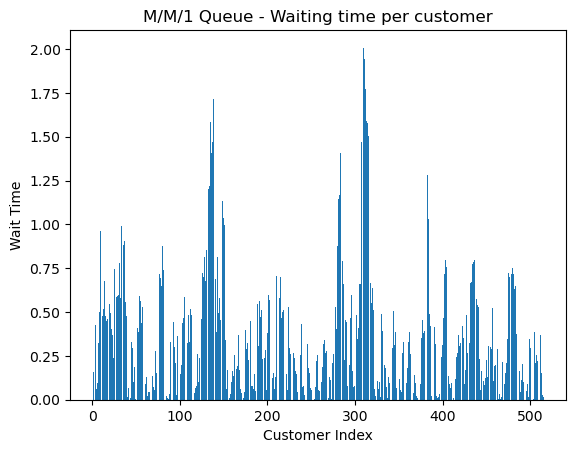

100.06084383369432


In [8]:
# Create a step plot using the time and queue length data from the simulation
plt.bar(np.linspace(1,len(s.waits),len(s.waits)),s.waits)   # The linspace creates an index from 1 to total number of customers who entered the system
plt.title("M/M/1 Queue - Waiting time per customer")        # Set the title of the plot
plt.xlabel("Customer Index")                                # Label the x-axis as 'Customer Index'
plt.ylabel("Wait Time")                                     # Label the y-axis as 'Wait Time'
plt.show()  

print(s.clock)

After the simulation, we can compute two key performance metrics: 
- `L`, the **average number of customers** in the system, and 
- `W`, the **average wait time** customers spend in the system. 

The following code calculates and displays these metrics from the simulation: **the average wait time of customers** (`W`) and **the average number of customers** (`L`) in the system during the simulation. 

In [9]:
s.waits = np.array(s.waits)                 # Convert the list of waiting times to array
W = s.waits.mean()                          # Calculate the average wait time across all customers
print("Average wait time: mean = %g" % (W)) # Print the average wait time across all customers

# Loop through the records of system states (time and queue length)
auc, last_t, last_l = 0, 0, 0
for t, l in s.in_systems:
    auc += (t - last_t) * last_l
    last_t, last_l = t, l
L = auc / last_t                            # Calculate the average number of customers in the system 

# Print the average number of customers in the system
print("Average number of customers in system = %g" % (L))   

Average wait time: mean = 0.367581
Average number of customers in system = 1.89189


### QUESTIONS
### Question 1
Using the above snippets of code, and potentially writing your own, can you answer the following questions.

Patients arrive to a walk-in blood test clinic at a rate of  10 patients per hour. 
The nurse is able to serve 11 patients per hour on average. 

Plot the Waiting Time Per Customer and Number of Customers in the system.

Calculate the following measures of system performance, assuming that there is a very large waiting room provided (n.b. run the code for duration = 200, don't worry about the realism of this!):
1. Average time a patient spends in the system, $W$
2. Average time a patient spends waiting for service, $W_q = W - 1/\mu$,
3. Average number of patients in the system, $L$,
4. Average number of patients in the queue waiting to be served, $L_q = L - \lambda/\mu$,
5. Probability of more than patients are waiting to be served (not including the patient being served) **[THIS IS TRICKY - DON'T WORRY IF YOU CAN'T GET IT!]**

In [10]:
np.random.seed(0) # Set the random seed for reproducibility

# Define the average inter-arrival time and service time (in minutes)
interarrival_time = 1/10      # Average time between customer arrivals
service_time = 1/11         # Average service time per customer

# Calculate the arrival rate (lambda) and service rate (mu) from the given times
lam = 1 / interarrival_time # Arrival rate (lambda)
mu = 1 / service_time       # Service rate (mu)

# Create a new Simulation object with the calculated arrival and service rates
s = Simulation(lam, mu)

# Define the total duration for the simulation in minutes
duration = 200

# Run the simulation by advancing the time until the clock reaches the specified duration
while s.clock < duration:
    s.advance_time() 

# After the simulation ends, print the first three wait times of customers
# print('Wait times: %r...' % s.waits[:3])  # Show the first 3 customers' wait times
# Print the first three entries in the system (arrival time and queue size at each point)
# print('Number of customers in system: %r...' % s.in_systems[:3])  # Show the first 3 system states (time and queue length)

s.waits = np.array(s.waits)                 # Convert the list of waiting times to array
W = s.waits.mean()                          # Calculate the average wait time across all customers
print("Average wait time in system: mean = %g" % (W)) # Print the average wait time across all customers
print("Average wait time in queue: mean = %g" % (W-1/mu)) # Print the average wait time across queue
# Loop through the records of system states (time and queue length)
auc, last_t, last_l = 0, 0, 0
for t, l in s.in_systems:
    auc += (t - last_t) * last_l
    last_t, last_l = t, l
L = auc / last_t                            # Calculate the average number of customers in the system 

# Print the average number of customers in the system
print("Average number of customers in system = %g" % (L)) 
print("Average number of customers in the queue = %g" % (L-lam/mu)) 

## Answer to Questions 5 above
sysvar = s.in_systems[:]
custime, num_sys = zip(*s.in_systems[:])

ctarr = np.diff(np.array(custime))
nsarr = np.array(num_sys[0:len(num_sys)-1])

print("Probability of more than 2 patients in the system (simulation) = %r" % (sum(ctarr[nsarr>2])/custime[-1]))
print("Probability of more than 2 patients in the system (theory) = %r" % (lam/mu)**3)

0.0795875: customer arrives (num_in_system=0->1)
0.17191: customer arrives (num_in_system=1->2)
0.193763: customer departs (num_in_system=2->1)
0.243858: customer departs (num_in_system=1->0)
0.25063: customer arrives (num_in_system=0->1)
0.308182: customer arrives (num_in_system=1->2)
0.345008: customer departs (num_in_system=2->1)
0.530534: customer arrives (num_in_system=1->2)
0.578894: customer arrives (num_in_system=2->3)
0.646364: customer departs (num_in_system=3->2)
0.714789: customer departs (num_in_system=2->1)
0.735784: customer arrives (num_in_system=1->2)
0.791101: customer departs (num_in_system=2->1)
0.797799: customer departs (num_in_system=1->0)
0.995609: customer arrives (num_in_system=0->1)
0.997652: customer arrives (num_in_system=1->2)
1.0039: customer departs (num_in_system=2->1)
1.14079: customer departs (num_in_system=1->0)
1.1764: customer arrives (num_in_system=0->1)
1.36188: customer departs (num_in_system=1->0)
1.56092: customer arrives (num_in_system=0->1)


### Question 2

If you managed the last one, try the following - using the above snippets of code, and potentially writing your own, can you answer the following questions.

On average patients call 111 at a rate of 4 calls per hour. Considering the call centre as a single server, it takes an average of 30 seconds per question with an average of 24 questions per phonecall. The service rates and arrival rates are assumed to be Markovian.

1. What is the average service rate of phone calls?
2. Plot the Waiting Time Per Customer and Number of Customers in the system.
    - If the service rate, $\mu = 3$, what do you notice happen to the plots? 

Calculate the following measures of system performance - under the two scenarios of $\mu$, that is your calculated value and for $\mu = 3$, assuming a large number of patients can wait (n.b. run the code for duration = 200, don't worry about the realism of this!):


3. Average number of patients in the system, $L$,
4. Average number of patients in the queue waiting to be served, $L_q = L - \lambda/\mu$,
5. Average time a patient spends in the system, $W$
6. Average time a patient spends waiting for service, $W_q = W - 1/\mu$,
7. Probability that 10 or more patients are waiting to be served (not including the patient being served) **[THIS IS TRICKY - DON'T WORRY IF YOU CAN'T GET IT!]**

**Solutions:**
1. 12 minutes, 5 per hour.
2. The queues keep growing with time for $\mu = 3$.

0.198969: customer arrives (num_in_system=0->1)
0.429774: customer arrives (num_in_system=1->2)
0.450155: customer departs (num_in_system=2->1)
0.560364: customer departs (num_in_system=1->0)
0.626575: customer arrives (num_in_system=0->1)
0.770455: customer arrives (num_in_system=1->2)
0.834207: customer departs (num_in_system=2->1)
1.32634: customer arrives (num_in_system=1->2)
1.44724: customer arrives (num_in_system=2->3)
1.49719: customer departs (num_in_system=3->2)
1.64772: customer departs (num_in_system=2->1)
1.81561: customer departs (num_in_system=1->0)
1.83946: customer arrives (num_in_system=0->1)
1.85788: customer arrives (num_in_system=1->2)
1.88067: customer arrives (num_in_system=2->3)
1.88578: customer arrives (num_in_system=3->4)
2.33265: customer arrives (num_in_system=4->5)
2.35911: customer departs (num_in_system=5->4)
2.7091: customer arrives (num_in_system=4->5)
2.76717: customer departs (num_in_system=5->4)
3.08822: customer departs (num_in_system=4->3)
3.21201

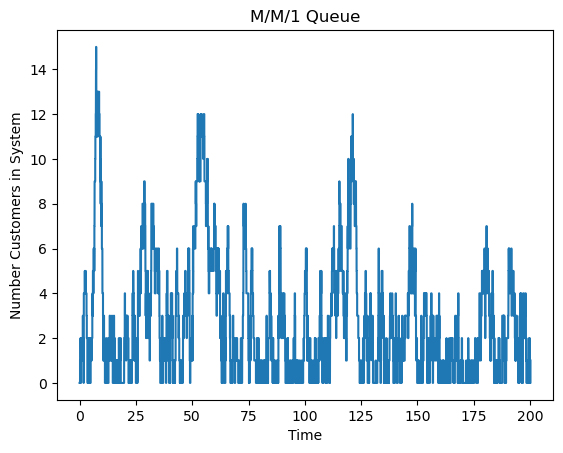

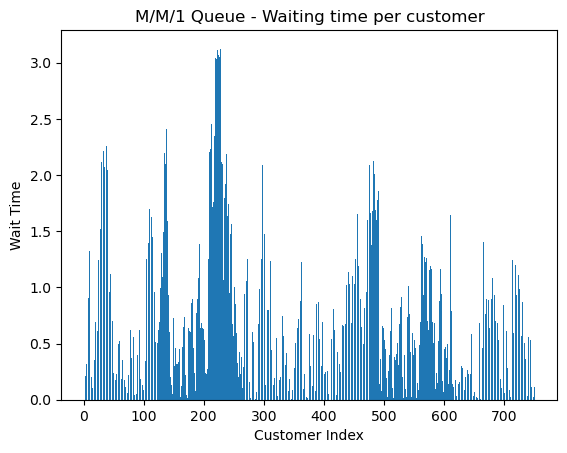

200.19264625556812
Average wait time in system: mean = 0.702899
Average wait time in queue: mean = 0.502899
Average number of customers in system = 2.63685
Average number of customers in the queue = 1.83685
Probability of 10 or more patients in the system (simulation) = 0.032020862853530924
Probability of 10 or more patients in the system (theory) = 0.10737418240000006


In [11]:
np.random.seed(0) # Set the random seed for reproducibility

# Define the average inter-arrival time and service time (in minutes)
interarrival_time = 1/4    # Average time between customer arrivals
service_time = 1/5         # Average service time per customer

# Calculate the arrival rate (lambda) and service rate (mu) from the given times
lam = 1 / interarrival_time # Arrival rate (lambda)
mu = 1 / service_time       # Service rate (mu)

# Create a new Simulation object with the calculated arrival and service rates
s = Simulation(lam, mu)

# Define the total duration for the simulation in minutes
duration = 200

# Run the simulation by advancing the time until the clock reaches the specified duration
while s.clock < duration:
    s.advance_time() 

# After the simulation ends, print the first three wait times of customers
# print('Wait times: %r...' % s.waits[:3])  # Show the first 3 customers' wait times
# Print the first three entries in the system (arrival time and queue size at each point)
# print('Number of customers in system: %r...' % s.in_systems[:3])  # Show the first 3 system states (time and queue length)

# Create a step plot using the time and queue length data from the simulation
plt.step(*zip(*s.in_systems[:]), where='post')  # The asterisk '*' here performs a special task - look it up online! Or see below
plt.title("M/M/1 Queue")                        # Set the title of the plot
plt.xlabel("Time")                              # Label the x-axis as 'Time'
plt.ylabel("Number Customers in System")        # Label the y-axis as 'Number of Customers in System'
plt.show()    

# Create a step plot using the time and queue length data from the simulation
plt.bar(np.linspace(1,len(s.waits),len(s.waits)),s.waits)   # The linspace creates an index from 1 to total number of customers who entered the system
plt.title("M/M/1 Queue - Waiting time per customer")        # Set the title of the plot
plt.xlabel("Customer Index")                                # Label the x-axis as 'Customer Index'
plt.ylabel("Wait Time")                                     # Label the y-axis as 'Wait Time'
plt.show()  

print(s.clock)

s.waits = np.array(s.waits)                 # Convert the list of waiting times to array
W = s.waits.mean()                          # Calculate the average wait time across all customers
print("Average wait time in system: mean = %g" % (W)) # Print the average wait time across all customers
print("Average wait time in queue: mean = %g" % (W-1/mu)) # Print the average wait time across queue

# Loop through the records of system states (time and queue length)
auc, last_t, last_l = 0, 0, 0
for t, l in s.in_systems:
    auc += (t - last_t) * last_l
    last_t, last_l = t, l
L = auc / last_t                            # Calculate the average number of customers in the system 

# Print the average number of customers in the system
print("Average number of customers in system = %g" % (L)) 
print("Average number of customers in the queue = %g" % (L-lam/mu)) 

## Answer to Questions 7 above
sysvar = s.in_systems[:]
custime, num_sys = zip(*s.in_systems[:])

ctarr = np.diff(np.array(custime))
nsarr = np.array(num_sys[0:len(num_sys)-1])

print("Probability of 10 or more patients in the system (simulation) = %r" % (sum(ctarr[nsarr>9])/custime[-1]))
print("Probability of 10 or more patients in the system (theory) = %r" % (lam/mu)**10)

### A bit of theory: Little's Law

Little's Law is actually rather big in terms of its implications and the insight it gives us into simple queueing systems.
It states that the mean number of customers in the system, $L$, relates to the time customers spend waiting in the system, $W$ (that is, both queueing and in service), as follows:
$$ \begin{equation*}
	L = \lambda W,
\end{equation*}$$
where $\lambda$ is the arrival rate of customers. 
Hence, if we know either $L$ or $W$, we can find the other!

`NOTE:` no assumptions around Markovian properties have been used here.

The following code checks if the simulation corresponds to the theory of **Little's Law** by calculating the ratio of **the average number of customers** (`L`) to **the average wait time** (`W`). 

So, according to Little's Law, this ratio should be approximately equal to the **arrival rate** ($\lambda$) set in the simulation. If the value is not close to the arrival rate, it may indicate that the simulation has not yet stabilised, and you might try increasing the duration of the simulation and repeating the steps to obtain more accurate results.

In [12]:
print('Calculated arrival rate: %g' % (L / W))
print('Actual arrival rate: %g' % (s.lambda_rate))

Calculated arrival rate: 3.75139
Actual arrival rate: 4


Now, experiment with different values of $\mu$ (the service rate) and $\lambda$ (the arrival rate). Pay particular attention to what happens when $\lambda > \mu$ and $\lambda < \mu$. Why?

When $\lambda > \mu$, the system will struggle to keep up with incoming customers, leading to an ever-growing queue. 
Conversely, when $\lambda < \mu$, the system can handle customers more efficiently, and the queue will likely stabilise over time.

The ratio of the two gives us an extra metric for the system called the `traffic intensity` or `utilisation` in the system, i.e. the average average occupancy of a server or resource during a specified period of time. This is denoted as follows:
$$ \rho = \lambda/\mu$$
- For $\rho < 1$ queues can reach some stable steady state - which is the behaviour we are often most concerned with when analytically studying queues. 
grow indefinitely.
- For $\rho > 1$ queues can grow indefinitely unless there is some other process to relieve the demand pressure, e.g. patients leaving queues if they are waiting too long, or temporary/time varying peaks and troughs in demand. These dynamics are not easily studied analytically, hence simulation becomes a helpful tool!


## Sweep values of $\lambda$

Since the actual value of the arrival rate, $\lambda$, is often unknown and if we lack appropriate date,  we can perform a **parameter sweep** by exploring a range of possible values for $\lambda$. As an example below, we will vary the arrival rate from 10% to 80% of the service rate, $\mu$. In the real world, we could then compare our system metrics (waiting time or number of people waiting) to learn about a real system. 

This allows us to observe how different values of $\lambda$ affect the system. If the arrival rate is greater than the service rate (i.e., $\lambda$ > $\mu$)), the queue will grow indefinitely, and the metrics $L$ and $W$ will primarily depend on how long the system runs. 

To conduct this sweep, we create an array of values for $\lambda$ , ranging from 10% to 80% of $\mu$, and run the simulation for each value to study the system's behavior under different arrival rates.

In [13]:
#Parameters for the new simulation 
service_time1 = 1/5
mu1 = 1 / service_time1
duration1 = 1000

# Create an array of lambda values ranging from 10% to 80% of the service rate
lam_array1 = np.linspace(0.1 * mu1, 0.8 * mu1, 51)  
print(lam_array1)

[0.5  0.57 0.64 0.71 0.78 0.85 0.92 0.99 1.06 1.13 1.2  1.27 1.34 1.41
 1.48 1.55 1.62 1.69 1.76 1.83 1.9  1.97 2.04 2.11 2.18 2.25 2.32 2.39
 2.46 2.53 2.6  2.67 2.74 2.81 2.88 2.95 3.02 3.09 3.16 3.23 3.3  3.37
 3.44 3.51 3.58 3.65 3.72 3.79 3.86 3.93 4.  ]


Run the following code to perform a parameter sweep over different values of the arrival rate $\lambda$ and calculate **the average waiting times** as well as **the average number of customers** in the system for each value of $\lambda$. 

In [14]:
sweep1 = [] # Initialise an empty list to store the average waiting times for each lambda

# Loop through each value of lambda in the lambda array
for lam1 in lam_array1:
    s1 = Simulation(lam1, mu1)# Initialise a new simulation object with the current lambda and the predefined mu
    
    # Run the simulation until the specified duration is reached
    while s1.clock < duration1:
        s1.advance_time()  
        
    # Calculate the average wait time across all customers
    s1.waits = np.array(s1.waits) 
    W1=s1.waits.mean()
    print("Average wait time: mean=%g" % (W1)) #Print the average wait time across all customers
    
    # Append the mean wait time to the sweep1 list for later analysis
    sweep1.append(W1)


2.20052: customer arrives (num_in_system=0->1)
2.52049: customer departs (num_in_system=1->0)
3.80195: customer arrives (num_in_system=0->1)
4.58908: customer departs (num_in_system=1->0)
5.57863: customer arrives (num_in_system=0->1)
5.58795: customer departs (num_in_system=1->0)
6.01988: customer arrives (num_in_system=0->1)
6.12365: customer departs (num_in_system=1->0)
7.85886: customer arrives (num_in_system=0->1)
8.15448: customer departs (num_in_system=1->0)
8.92462: customer arrives (num_in_system=0->1)
9.17223: customer departs (num_in_system=1->0)
12.0447: customer arrives (num_in_system=0->1)
12.121: customer departs (num_in_system=1->0)
19.797: customer arrives (num_in_system=0->1)
20.0068: customer departs (num_in_system=1->0)
24.0543: customer arrives (num_in_system=0->1)
24.2166: customer departs (num_in_system=1->0)
26.7608: customer arrives (num_in_system=0->1)
27.0552: customer departs (num_in_system=1->0)
31.5381: customer arrives (num_in_system=0->1)
31.5707: custom

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



The following code generates a plot to visualise the relationship between the arrival rate $\lambda$ and the average waiting time in the system ($W$). It plots the values of $\lambda$ (from the `lam_array1`) against the corresponding average waiting times (stored in `sweep1`) as discrete points. 

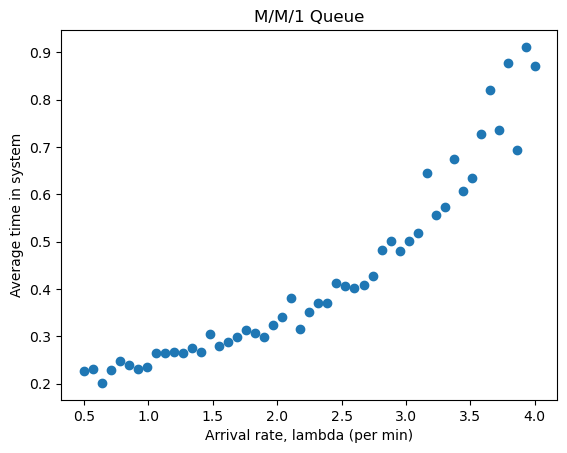

In [15]:
plt.plot(lam_array1,sweep1,'o')
plt.title("M/M/1 Queue")
plt.xlabel("Arrival rate, lambda (per min)")
plt.ylabel("Average time in system")
plt.show()

If we imagine that this range of values represents arrival rates on different days, we can use the average value of $W$, for a range of values of $\lambda$, to compare different queueing strategies.

In [16]:
W_avg1 = np.mean(sweep1)
W_avg1

0.42858614493448116

### A bit more theory - Stationary (Steady State) Distributions
For simple, Markovian queues We can find limiting solutions of queueing systems to find analytical expressions of different metrics.
    
In such cases we consider the `system time` to grow indefinitely, such that $t \rightarrow \infty$  the number of customers in system can tend to a limit - which will be some definable distribution.

For the $M/M/1$ queue - we can find the `limiting` or `stationary distribution`, to be a defined set of probabilities $\left\{ \pi_n : n \geq 0 \right\}$,  if and only if: 
$$\begin{equation*}
	\sum_0^\infty \pi_n = 1, \text{ i.e. } \pi_0 (1+\rho+\rho^2+...) = 1,
\end{equation*}$$
where $\rho = \lambda/\mu$. The above sum $\sum_0^\infty \rho^n$ is bounded if and only if $|\rho| < 1$, i.e. $\lambda < \mu$ - which matches what we discussed above! 
      
(ASIDE: summing to 1 should make sense to you since the total probability of a given distribution always sums to 1).

Here: $\pi_i$ is the probability that the stationary process contains $i$ customers, including those in service.
Thus, for $\pi_0 > 0$ and $\lambda < \mu$, (i.e. arrival rate less than service rate) we obtain:
$$\begin{equation*}
	1 = \pi_0 \sum_0^\infty \rho^n = \frac{\pi_0}{1-\rho} \text{ (using the sum of a geometric progression)},
\end{equation*}$$
giving			
$$\begin{equation*}
	\pi_0 = (1 - \rho) \text{ and } \pi_n = \rho^n (1 - \rho) \text{ for } n > 0.
\end{equation*}$$
For many practical applications the stationary behaviour of the queue is of most interest.

### Why is this useful for us!
Well, it means we can define the waiting time and queue lengths analytically and compare with our simulation (to check all is present and correct).
And what we should find is the following for the average number of people in the system $E[L]$ and the average waiting time $E[W]$:

$$ \begin{equation*} E[L] = \frac{\lambda}{\mu-\lambda} = \lambda E[W]. \end{equation*}$$

If you want to consider the queue only, and not those in service as well, we have a formula for that too!
$$ \begin{equation*} E[L^{(q)}] = \frac{\rho^2}{(1-\rho)} = \lambda E[W^{(q)}]. \end{equation*} $$

Note Little's law in action here!

>ASIDE: for those of you who'd like to see a derivation of these - see below!
>$$  \begin{align*}
>        \begin{aligned}
>            E[L] &= \sum_{n = 0}^\infty n\pi_n = \sum_{n = 0}^\infty n\rho^n (1-\rho) = \rho(1-\rho) \sum_{n = 0}^\infty (n\rho^{(n-1)}) = \rho(1-\rho) \sum_{n = 0}^\infty \frac{d}{d\rho}(\rho^n) \\
>            &= \rho(1-\rho) \frac{d}{d\rho} \sum_{n = 0}^\infty \rho^n = \frac{\rho(1-\rho)}{(1-\rho)^2} = \frac{\rho}{(1-\rho)} = \frac{\lambda}{\mu-\lambda} = \lambda E[W].
>		\end{aligned}
>\end{align*} $$
>
>$$ \begin{align*}
>	\begin{aligned}
>		E[L^{(q)}] &= \sum_{n = 0}^\infty n\pi_{n+1} =\sum_{n = 0}^\infty n\rho^{n+1} (1-\rho) =\rho^2 (1-\rho) \sum_{n = 0}^\infty n\rho^{n-1} \\
>		&=\frac{\rho^2 (1-\rho)}{(1-\rho)^2} =\frac{\rho^2}{(1-\rho)} = \lambda E[W^{(q)}].
>	\end{aligned}
>\end{align*} $$

The following function plots the theoretical value of $W$ as a function of $\lambda$.

In [17]:
W_array1 = 1 / (mu1 - lam_array1)

Use this function to plot the theoretical results, then plot your simulation results again on the same graph.  How do they compare?

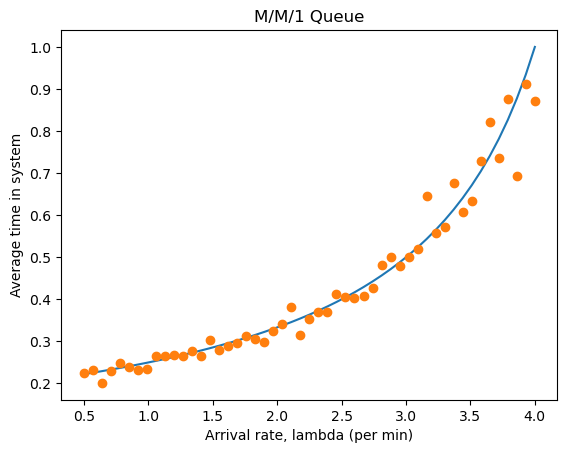

In [18]:
plt.plot(lam_array1,W_array1, '-')

plt.plot(lam_array1,sweep1,'o')
plt.title("M/M/1 Queue")
plt.xlabel("Arrival rate, lambda (per min)")
plt.ylabel("Average time in system")
plt.show()

## QUESTION

1. Run the above $\lambda$ sweep analysis again, but extending to 1.5 $\times \mu$ and see how the plots change.
2. Can you implement code to calculate $L_q$ and $W_q$ in the above analysis?
3. Can you implement a similar analysis, but sweeping over $\mu$ values instead - for $\lambda = 1/8$ and $\mu = 1.5 \lambda$ to $5 \lambda$.

You can initiate the code with the following:
```
lam2 = 1 / 8
duration2=100

# Create an array of mu values ranging from 20% to 200% of lambda
mu_array2 = np.linspace(1.5*lam2, 5.0 * lam2, 10)
mu_array2
```

**Solution** code below for mu sweep - try yourself first!

To better understand the impact of the service rate, $\mu$, we can perform a **parameter sweep** by exploring a range of possible values for $\mu$. This will help us observe how different service rates affect the system’s performance. We can vary $\mu$ from 150% to 500% of the arrival rate, $\lambda$. 

To conduct this sweep, create an array of values for $\mu$, ranging from 150% to 500% of $\lambda$, and run the simulation for each value to analyse how the service rate impacts system performance.

4.1154: customer arrives (num_in_system=0->1)
9.66427: customer departs (num_in_system=1->0)
11.7383: customer arrives (num_in_system=0->1)
12.2514: customer departs (num_in_system=1->0)
18.3068: customer arrives (num_in_system=0->1)
18.3625: customer departs (num_in_system=1->0)
22.9547: customer arrives (num_in_system=0->1)
26.3563: customer arrives (num_in_system=1->2)
27.8063: customer departs (num_in_system=2->1)
31.2461: customer departs (num_in_system=1->0)
34.6369: customer arrives (num_in_system=0->1)
38.4714: customer departs (num_in_system=1->0)
43.6407: customer arrives (num_in_system=0->1)
43.9085: customer departs (num_in_system=1->0)
70.2014: customer arrives (num_in_system=0->1)
76.4064: customer arrives (num_in_system=1->2)
79.4673: customer arrives (num_in_system=2->3)
80.0398: customer departs (num_in_system=3->2)
82.1553: customer arrives (num_in_system=2->3)
84.3574: customer arrives (num_in_system=3->4)
89.5489: customer departs (num_in_system=4->3)
91.1992: custo

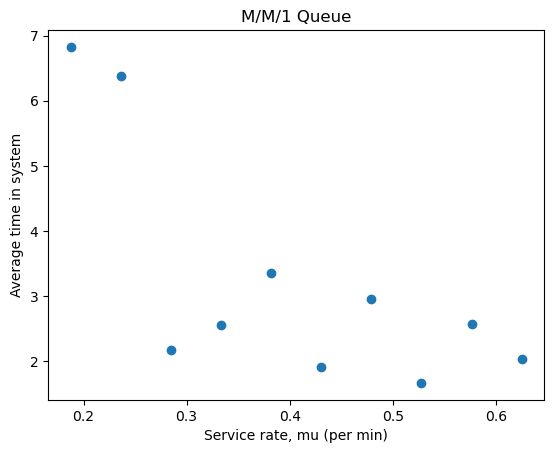

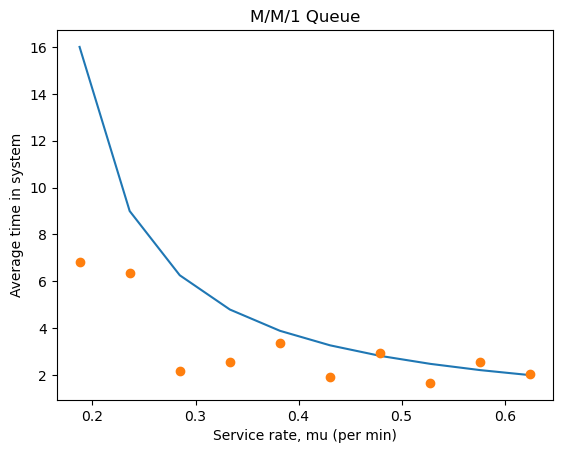

In [19]:
lam2 = 1 / 8
duration2=100

# Create an array of mu values ranging from 20% to 200% of lambda
mu_array2 = np.linspace(1.5*lam2, 5.0 * lam2, 10)
mu_array2


sweep2=[] # Initialise an empty list to store the average waiting times for each mu
for mu2 in mu_array2:
    s2=Simulation(lam2,mu2) # Initialise a new simulation object with the current values of lambda and mu
    # Run the simulation until the specified duration is reached
    while s2.clock<duration2:
        s2.advance_time()

    # Calculate the average wait time across all customers
    s2.waits = np.array(s2.waits)
    W2=s2.waits.mean()
    print("Average wait time: mean=%g" % (W2)) #Print the average wait time across all customers
    
    auc, last_t, last_l = 0, 0, 0
    for t, l2 in s2.in_systems:
        auc += (t-last_t)*last_l
        last_t, last_l = t, l
    L2 = auc / last_t # Calculate the average number of customers in the system 
    print("avg number of customers in system = %g" % L2)
    sweep2.append(W2) # Append the mean wait time to the sweep2 list for later analysis

#### Plot to visualise the relationship between the service rate $\mu$ and the average waiting time in the system ($W$). 

plt.plot(mu_array2,sweep2,'o')
plt.title("M/M/1 Queue")
plt.xlabel("Service rate, mu (per min)")
plt.ylabel("Average time in system")
plt.show()

#### Calculate the theoretical value of $W$ as a function of $\mu$.
W_array2 = 1 / (mu_array2 - lam2)

#### Use this function to plot the theoretical results, then plot your simulation results again on the same graph.  How do they compare?
plt.plot(mu_array2,W_array2, '-')

plt.plot(mu_array2,sweep2,'o')
plt.title("M/M/1 Queue")
plt.xlabel("Service rate, mu (per min)")
plt.ylabel("Average time in system")
plt.show()


## Sweep values of $\mu$ and $\lambda$

In this section, we are performing a **parameter sweep** by varying both the arrival rate (`lambda`) and the service rate (`mu`). We explore a range of values for each parameter:

- **`lam3_array`**: A range of values for the arrival rate (`lambda`) from 0.02 to 0.1.
- **`mu3_array`**: A range of values for the service rate (`mu`) from 0.2 to 0.5.

For each combination of `lambda` and `mu`, the simulation is run, and we calculate the average waiting time and average number of customers in the system. The results are stored in `sweep3_1`, which represents the average waiting time for each combination of parameters. 

In [20]:
lam3_array =np.linspace(0.02, 0.1, 10) # Create an array of lambda values 
mu3_array  =np.linspace(0.2,0.5, 10) # Create an array of mu values 
sweep3_1   =np.zeros((len(lam3_array), len(mu3_array))) # Initialise an empty list to store the average waiting times
duration   = 100
for i in range(len(lam3_array)):    
    for j in range(len(mu3_array)):
        s3=Simulation(lam3_array[i],mu3_array[j]) # Initialise a new simulation object with the current values of lambda and mu
        while s3.clock<duration:
            s3.advance_time()
        s3.waits = np.array(s3.waits)
        W3=s3.waits.mean()  # Calculate the average wait time across all customers
        print("Average wait time: mean=%g" % (W3)) 
        
        auc, last_t, last_l = 0, 0, 0
        for t, l in s3.in_systems:
            auc += (t-last_t)*last_l
            last_t, last_l = t, l
        L3=(auc/last_t)   # Calculate the average number of customers in the system 
        print("avg number of customers in system = %g" % L3)
        sweep3_1[i,j]=W3  # Append the mean wait time to the sweep2 list for later analysis

23.4332: customer arrives (num_in_system=0->1)
30.428: customer arrives (num_in_system=1->2)
36.1178: customer departs (num_in_system=2->1)
44.2316: customer arrives (num_in_system=1->2)
47.3864: customer arrives (num_in_system=2->3)
58.3388: customer departs (num_in_system=3->2)
65.6763: customer departs (num_in_system=2->1)
78.389: customer departs (num_in_system=1->0)
79.5079: customer arrives (num_in_system=0->1)
92.7458: customer departs (num_in_system=1->0)
93.3669: customer arrives (num_in_system=0->1)
95.5044: customer departs (num_in_system=1->0)
102.248: customer arrives (num_in_system=0->1)
Average wait time: mean=18.0697
avg number of customers in system = 1.06034
29: customer arrives (num_in_system=0->1)
30.9627: customer departs (num_in_system=1->0)
68.3284: customer arrives (num_in_system=0->1)
68.6553: customer departs (num_in_system=1->0)
78.446: customer arrives (num_in_system=0->1)
81.1514: customer departs (num_in_system=1->0)
305.177: customer arrives (num_in_syste

C:\Users\va24444\AppData\Local\Temp\ipykernel_23780\2859719235.py:11: RuntimeWarning: Mean of empty slice.
  W3=s3.waits.mean()  # Calculate the average wait time across all customers
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Now, we will visualise the results of our parameter sweep using a heatmap. The heatmap will display the average waiting time for each combination of arrival rate (`lambda`) and the service rate (`mu`).

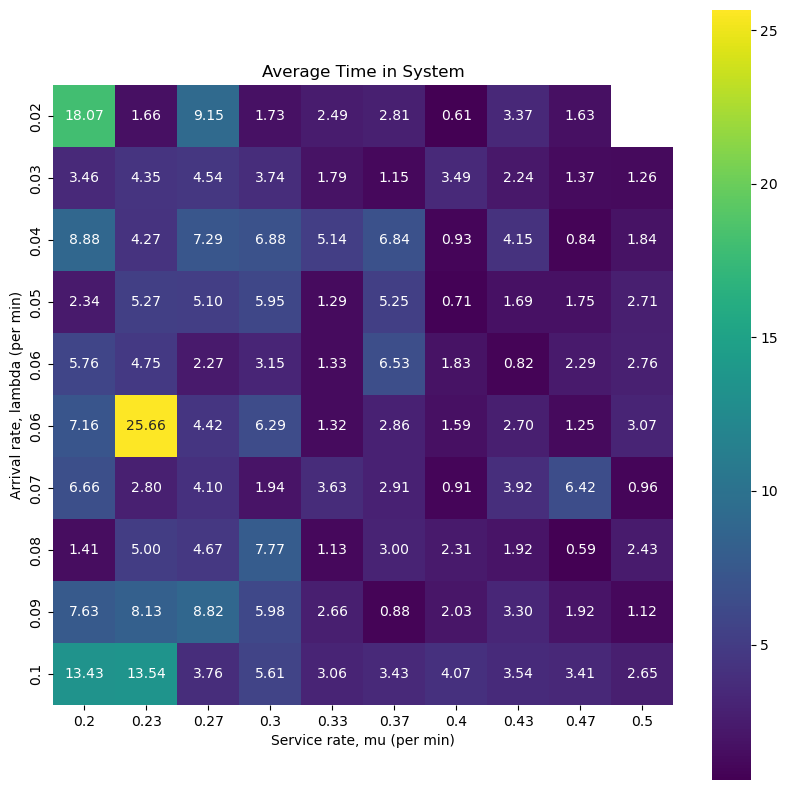

In [21]:
import seaborn as sns

# Set the figure size for the heatmap
plt.figure(figsize=(10, 10))  

# Round the values of mu and lambda arrays for cleaner x and y axis labels
x_labels = np.round(mu3_array, 2) 
y_labels = np.round(lam3_array, 2) 

# Create a heatmap using seaborn with the given data
sns.heatmap(sweep3_1, 
            cmap='viridis',  # Choose a color palette
            xticklabels=x_labels,  # Set the x-axis labels as rounded mu values
            yticklabels=y_labels,  # Set the y-axis labels as rounded lambda values
            annot=True,  # Annotate each cell with its value
            fmt='.2f',  # Format annotations to two decimal places
            square=True)  # Ensure the heatmap is square-shaped
plt.title('Average Time in System')# Add a title to the heatmap

# Label the x-axis and y-axis
plt.xlabel('Service rate, mu (per min)')
plt.ylabel('Arrival rate, lambda (per min)')     

plt.show() # Show the plot


## QUESTION

If it costs the healthcare service £$10000 \mu$ to run the service, but delays cost the service £$500 W$ for delays - what are the best choices for $\mu$ for each rate $\lambda$ above given an overall budget of £$5000$ - is it feasible given the budget to run the service at this cost?

**Solution** below - try yourself first!

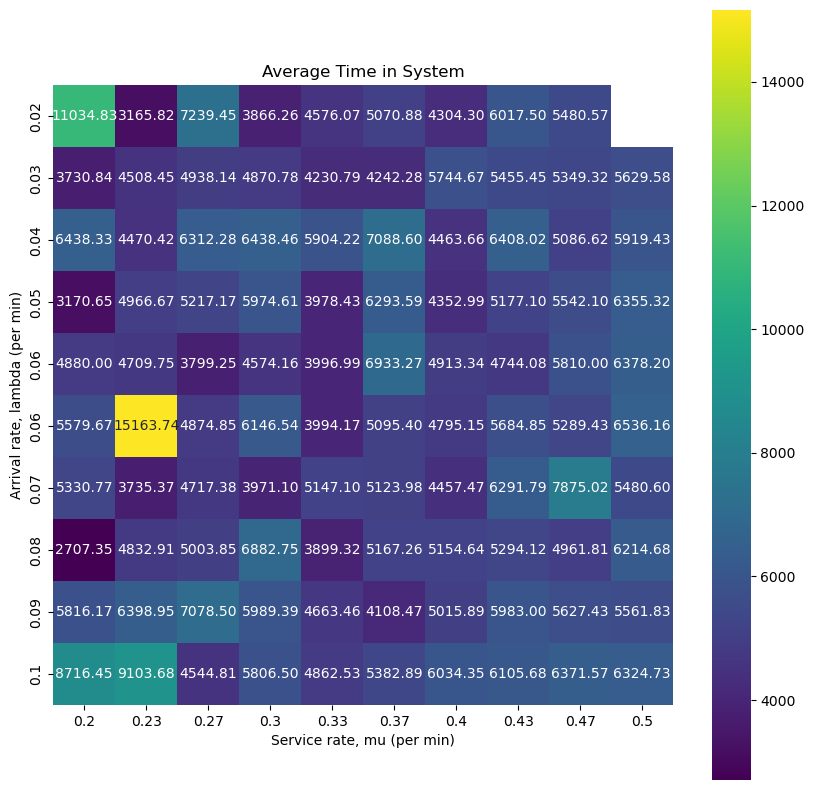

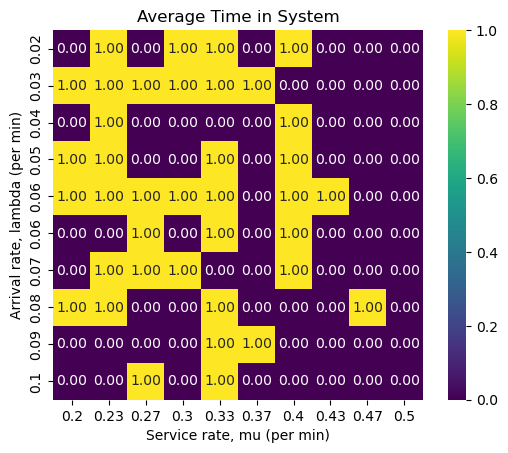

In [22]:
import seaborn as sns
 
# Set the figure size for the heatmap
plt.figure(figsize=(10, 10))  
 
# Round the values of mu and lambda arrays for cleaner x and y axis labels
x_labels = np.round(mu3_array, 2) 
y_labels = np.round(lam3_array, 2) 

# Create a heatmap using seaborn with the given data
sns.heatmap(sweep3_1*500+mu3_array*10000, 
            cmap='viridis',  # Choose a color palette
            xticklabels=x_labels,  # Set the x-axis labels as rounded mu values
            yticklabels=y_labels,  # Set the y-axis labels as rounded lambda values
            annot=True,  # Annotate each cell with its value
            fmt='.2f',  # Format annotations to two decimal places
            square=True)  # Ensure the heatmap is square-shaped
plt.title('Average Time in System')# Add a title to the heatmap

# Label the x-axis and y-axis
plt.xlabel('Service rate, mu (per min)')
plt.ylabel('Arrival rate, lambda (per min)')     

plt.show()# Show the plot 

answer = ((sweep3_1*500+mu3_array*10000) < 5000)
# Create a heatmap using seaborn with the given data
sns.heatmap(answer, 
            cmap='viridis',  # Choose a color palette
            xticklabels=x_labels,  # Set the x-axis labels as rounded mu values
            yticklabels=y_labels,  # Set the y-axis labels as rounded lambda values
            annot=True,  # Annotate each cell with its value
            fmt='.2f',  # Format annotations to two decimal places
            square=True)  # Ensure the heatmap is square-shaped
plt.title('Average Time in System')# Add a title to the heatmap

# Label the x-axis and y-axis
plt.xlabel('Service rate, mu (per min)')
plt.ylabel('Arrival rate, lambda (per min)')     

plt.show()# Show the plot 